In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [4]:
import pandas as pd
df = pd.read_csv("/content/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
print(df.shape)
df.info()

(23858, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23858 entries, 0 to 23857
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    23858 non-null  int64  
 1   V1      23858 non-null  float64
 2   V2      23858 non-null  float64
 3   V3      23858 non-null  float64
 4   V4      23858 non-null  float64
 5   V5      23858 non-null  float64
 6   V6      23858 non-null  float64
 7   V7      23858 non-null  float64
 8   V8      23858 non-null  float64
 9   V9      23858 non-null  float64
 10  V10     23858 non-null  float64
 11  V11     23858 non-null  float64
 12  V12     23858 non-null  float64
 13  V13     23858 non-null  float64
 14  V14     23858 non-null  float64
 15  V15     23858 non-null  float64
 16  V16     23858 non-null  float64
 17  V17     23858 non-null  float64
 18  V18     23858 non-null  float64
 19  V19     23858 non-null  float64
 20  V20     23858 non-null  float64
 21  V21     23858 non-null 

In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [7]:
df['Class'].value_counts()

,count
Class,
0.0,23769
1.0,88


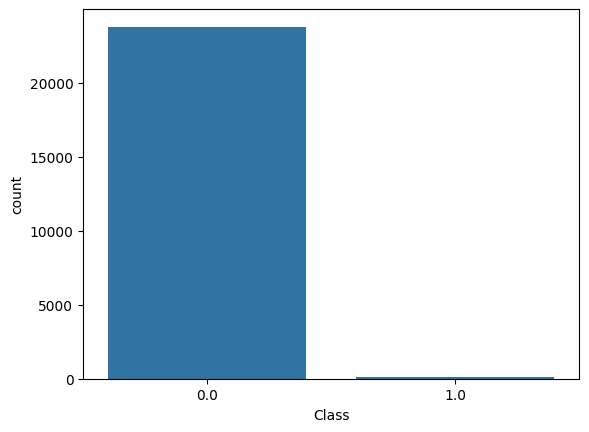

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.show()

In [ ]:
df_cleaned = df.dropna()
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

In [10]:
df_cleaned = df.dropna()
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
rf_pred = rf.predict(X_test)
print(rf_pred)

[0. 0. 0. ... 0. 0. 0.]


In [14]:
print("accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("f1_score:", f1_score(y_test, rf_pred))

accuracy: 0.9989522212908634
Precision: 0.8823529411764706
Recall: 0.8333333333333334
f1_score: 0.8571428571428571


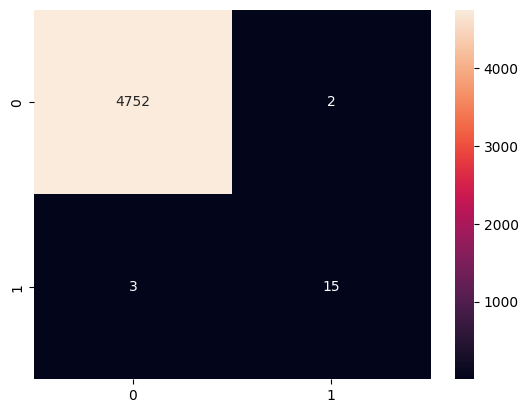

In [15]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

In [17]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4754
         1.0       0.88      0.83      0.86        18

    accuracy                           1.00      4772
   macro avg       0.94      0.92      0.93      4772
weighted avg       1.00      1.00      1.00      4772



In [18]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [19]:
xgb_pred = xgb.predict(X_test)

In [20]:
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Precision:",
      precision_score(y_test, xgb_pred))

print("Recall:",
      recall_score(y_test, xgb_pred))

print("F1 Score:",
      f1_score(y_test, xgb_pred))

Accuracy: 0.9995808885163453
Precision: 1.0
Recall: 0.8888888888888888
F1 Score: 0.9411764705882353


In [21]:
results = pd.DataFrame({

    'Model':
    ['Random Forest',
     'XGBoost'],

    'Precision':
    [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    'Recall':
    [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    'F1':
    [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Model,Precision,Recall,F1
0,Random Forest,0.882353,0.833333,0.857143
1,XGBoost,1.000000,0.888889,0.941176


In [4]:
import numpy as np
import pandas as pd
df = pd.read_csv("/content/creditcard.csv")
df["LogAmount"] = np.log1p(df["Amount"])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,LogAmount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0,5.014760
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0,1.305626
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0,5.939276
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0,4.824306
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0,4.262539


In [22]:
importance = pd.DataFrame({

    'Feature':
    X.columns,

    'Importance':
    rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
12,V12,0.119090
17,V17,0.108232
14,V14,0.100445
11,V11,0.082970
4,V4,0.077271
9,V9,0.075231
10,V10,0.064733
26,V26,0.044698
16,V16,0.039195
18,V18,0.030231


In [25]:
sample = X_test.iloc[0:1]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Fraud Transaction")
else:
    print("Legitimate Transaction")

Legitimate Transaction


In [26]:
print(y_test.iloc[0])

0.0


In [27]:
import joblib
joblib.dump(rf, 'fraud_model.pkl')

['fraud_model.pkl']

In [30]:
with open('app.py', 'w') as f:
    f.write("# Placeholder for your app code, e.g., Flask or FastAPI\n")
print("Created app.py")

Created app.py


In [31]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.4 MB/s eta 0:00:00


### How to Run Your Streamlit App in Colab

1.  **Save your Streamlit code to a Python file (e.g., `app.py`)**: The code in the previous cell needs to be written to a `.py` file to be run by Streamlit.
2.  **Install `localtunnel` (or `ngrok`)**: These tools create a public URL for your local server.
3.  **Run Streamlit via the public URL**.

Here's how you can do that:

In [33]:
# Write the Streamlit code to app.py
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("/content/fraud_model.pkl")

st.title("AI Fraud Detection System")

uploaded_file = st.file_uploader(
    "Upload Transaction CSV",
    type=["csv"]
)

if uploaded_file:
    df = pd.read_csv(uploaded_file)
    st.write(df.head())
    predictions = model.predict(df)
    df["Prediction"] = predictions
    st.write(df)
    fraud_count = (predictions == 1).sum()
    st.metric(
        "Fraud Transactions",
        fraud_count
    )


Overwriting app.py


In [34]:
# Install localtunnel
!npm install localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 2s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙npm notice
npm notice New major version of npm available! 10.8.2 -> 11.16.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.16.0
npm notice To update run: npm install -g npm@11.16.0
npm notice
⠙

Now, run the Streamlit app. After executing the cell below, a public URL will be provided, which you can click to access your Streamlit application. It might ask you to confirm a connection, just click 'Click to Continue' or 'Continue to localhost' if prompted.